In [1]:
import sys
sys.path.insert(0, "..")  # make src/ importable from notebooks/
import sqlite3
import re
from pathlib import Path
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize
import textstat
import pysentiment2 as ps2
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

# Import improved cleaning from src (handles SEC EDGAR + Motley Fool)
from src.sentiment import (
    clean_transcript, clean_and_split_transcript,
    chunk_text, compute_paragraph_vader, compute_all_sentiment_features,
)

# Try DirectML (AMD GPU) first, graceful fallback to CPU
try:
    import torch_directml
    DEVICE = torch_directml.device()
except (ImportError, OSError, RuntimeError) as e:
    DEVICE = torch.device('cpu')
    print(f'DirectML unavailable ({type(e).__name__}); falling back to {DEVICE}')
print(f'PyTorch device: {DEVICE}')

DB_PATH = '../data/market.db'
TRANSCRIPTS_DIR = Path('../data/transcripts')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline



PyTorch device: privateuseone:0


In [2]:
# ---- Load transcript METADATA (never the text blobs — those stream later) --
from src.transcripts_io import META_COLS, fetch_sections

# Knobs for smoke runs on the 33k-call universe:
MIN_PUB_DATE = '2016-07-01'   # match price coverage (START_DATE in src.config)
TICKER_FILTER = None          # e.g. ['MSFT','NVDA'] for a quick test
MAX_TRANSCRIPTS = None        # None = full universe; set an int (e.g. 500) for a smoke run

conn = sqlite3.connect(DB_PATH)
try:
    tx_df = pd.read_sql(
        f"SELECT {', '.join(META_COLS)} FROM transcripts_text "
        f"WHERE pub_date >= ? ORDER BY ticker, year, quarter",
        conn, params=(MIN_PUB_DATE,), parse_dates=['pub_date'])
    TEXT_SOURCE = 'db'
except Exception:
    tx_df = pd.DataFrame()
    TEXT_SOURCE = None

if len(tx_df) == 0:
    # ---- Legacy fallback: EDGAR-scraped .txt files (02_transcripts) ----
    TEXT_SOURCE = 'files'
    tx_df = pd.read_sql(
        "SELECT * FROM transcripts WHERE status = 200 ORDER BY ticker, year, quarter",
        conn, parse_dates=['pub_date', 'scrape_time'])
    tx_df['file_exists'] = tx_df['file_path'].apply(lambda p: Path(p).exists())
    missing = tx_df[~tx_df['file_exists']]
    if len(missing) > 0:
        print(f'WARNING: {len(missing)} DB rows have no local file — dropping')
    tx_df = tx_df[tx_df['file_exists']].copy()
conn.close()

if TICKER_FILTER:
    tx_df = tx_df[tx_df['ticker'].isin(TICKER_FILTER)].copy()
if MAX_TRANSCRIPTS:
    tx_df = tx_df.head(MAX_TRANSCRIPTS).copy()

print(f'Transcript source: {TEXT_SOURCE}')
print(f'Transcripts to process: {len(tx_df):,}')
if len(tx_df) == 0:
    print('\n⚠️  No transcripts. Run 02b_ingest_hf_transcripts.ipynb (preferred) '
          'or 02_transcripts.ipynb first.')
else:
    print(f'Tickers: {tx_df["ticker"].nunique()}')
    print(f'Date range: {tx_df["pub_date"].min().date()} to {tx_df["pub_date"].max().date()}')
    if TEXT_SOURCE == 'db':
        print(f'Q&A coverage (speaker-based): {tx_df["has_qa"].mean():.1%}')
        print(f'Total words: {tx_df["n_words_full"].sum():,}')

Transcript source: db


Transcripts to process: 18,392
Tickers: 623
Date range: 2016-07-06 to 2025-05-15
Q&A coverage (speaker-based): 98.5%
Total words: 158,492,767


In [3]:
# ---- Lazy section access ------------------------------------------------
# We do NOT build a dict of 33k cleaned transcripts (that would be several
# GB of RAM). Instead, get_sections(ticker, quarter, year) fetches and
# decompresses ONE transcript on demand; the feature loops below call it,
# compute numbers, and discard the text immediately.

if TEXT_SOURCE == 'db':
    _sec_conn = sqlite3.connect(DB_PATH)

    def get_sections(ticker, quarter, year):
        """Speaker-split sections from transcripts_text, cleaned."""
        secs = fetch_sections(_sec_conn, ticker, quarter, year)
        return {k: clean_transcript(v) for k, v in secs.items()}
else:
    _file_paths = {(r.ticker, r.quarter, r.year): r.file_path
                   for r in tx_df.itertuples()}

    def get_sections(ticker, quarter, year):
        """Legacy: read .txt file, regex-split, clean."""
        fp = _file_paths.get((ticker, quarter, year))
        if fp is None:
            return {}
        raw = Path(fp).read_text(encoding='utf-8')
        return clean_and_split_transcript(raw)

# Keys to iterate (order matches tx_df)
tx_keys = list(tx_df[['ticker', 'quarter', 'year']].itertuples(index=False, name=None))

# Preview one transcript to sanity-check the pipeline
if tx_keys:
    sample = get_sections(*tx_keys[0])
    print(f'Sample {tx_keys[0]}: sections={list(sample)}')
    full = sample.get('full', '')
    print(f'  full: {len(full.split()):,} words | first 250 chars:')
    print(' ', full[:250])
    if 'qa' in sample:
        print(f'  qa:   {len(sample["qa"].split()):,} words')

Sample ('A', 'q3', 2016): sections=['prepared_remarks', 'qa', 'full']
  full: 8,445 words | first 250 chars:
  Good day ladies and gentlemen, and welcome to the Third Quarter 2016 Agilent Technologies Earnings Conference Call. [Operator Instructions] As a reminder, today's program is being recorded. Thank you, Jonathan, and welcome, everyone, to Agilent's Thi
  qa:   8,128 words


In [4]:
import time as _time

# ---- Checkpointing: 03 is resumable so a crash/power-loss never wipes it ---
# Stage A (this cell): VADER/LM/readability -> `vaderlm_scores` table, saved on
#   completion. A mid-stage interruption redoes this stage (~<1h, parallel).
# Stage B (FinBERT cell): incremental per-transcript checkpoint to
#   `finbert_scores` — survives a crash down to the last ~100 transcripts.
# To resume after an interruption: re-run  run_pipeline.py --from 03
# To recompute everything from scratch: set RESET_CHECKPOINT = True once.
RESET_CHECKPOINT = False

def _serial_features(keys):
    """Single-process VADER+LM+readability fallback over section dicts."""
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    import pysentiment2 as ps2
    v, l = SentimentIntensityAnalyzer(), ps2.LM()
    rows = []
    t0 = _time.time()
    for n, (ticker, quarter, year) in enumerate(keys):
        secs = get_sections(ticker, quarter, year)
        row = {'ticker': ticker, 'quarter': quarter, 'year': year,
               'has_qa': int('qa' in secs)}
        for name, text in secs.items():
            row.update(compute_all_sentiment_features(text, v, l, prefix=name))
        rows.append(row)
        if (n + 1) % 500 == 0:
            el = _time.time() - t0
            print(f'  [{n+1:,}/{len(keys):,}] {el:.0f}s, '
                  f'~{el/(n+1)*(len(keys)-n-1)/60:.0f} min left')
    return pd.DataFrame(rows)

_ck = sqlite3.connect(DB_PATH)
if RESET_CHECKPOINT:
    _ck.execute('DROP TABLE IF EXISTS vaderlm_scores')
    _ck.execute('DROP TABLE IF EXISTS finbert_scores')
    _ck.commit()
    print('RESET_CHECKPOINT=True -> dropped vaderlm_scores + finbert_scores')

EVASIVENESS_COLS = ['n_turns', 'n_exec_speakers', 'n_analyst_speakers',
                    'n_analyst_questions', 'analyst_q_words', 'exec_a_words',
                    'answer_question_ratio', 'hedge_per_1k']

# ---- Stage A: resume from checkpoint if it already covers our keys --------
df_sent = None
_exists = _ck.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='vaderlm_scores'").fetchone()
if _exists:
    _cached = pd.read_sql('SELECT * FROM vaderlm_scores', _ck)
    _ckkeys = set(_cached[['ticker', 'quarter', 'year']].itertuples(index=False, name=None))
    if set(tx_keys) <= _ckkeys:
        keys_df = pd.DataFrame(tx_keys, columns=['ticker', 'quarter', 'year'])
        df_sent = keys_df.merge(_cached, on=['ticker', 'quarter', 'year'], how='left')
        print(f'Resumed VADER/LM from checkpoint: {len(df_sent):,} rows (recompute skipped)')

_t0 = _time.time()
if df_sent is None:
    if TEXT_SOURCE == 'db':
        # Multiprocess scoring — pure-Python regex/dict work parallelizes well;
        # falls back to serial if the process pool can't start.
        try:
            from src.features_parallel import compute_sentiment_features_parallel
            df_sent = compute_sentiment_features_parallel(DB_PATH, tx_keys, log_every=1000)
        except Exception as e:
            print(f'Parallel path failed ({type(e).__name__}: {e}); using serial fallback.')
            df_sent = _serial_features(tx_keys)
    else:
        df_sent = _serial_features(tx_keys)   # legacy .txt-file universe
    if TEXT_SOURCE == 'db':
        df_sent = df_sent.merge(
            tx_df[['ticker', 'quarter', 'year'] + EVASIVENESS_COLS],
            on=['ticker', 'quarter', 'year'], how='left')
    df_sent.to_sql('vaderlm_scores', _ck, if_exists='replace', index=False)
    _ck.commit()
    print(f'Checkpointed VADER/LM -> vaderlm_scores ({len(df_sent):,} rows)')
_ck.close()

print(f'\nVADER + LM ready for {len(df_sent):,} transcripts in {(_time.time()-_t0)/60:.1f} min')
print(f'  Rows with Q&A section: {df_sent["has_qa"].sum():,} ({df_sent["has_qa"].mean():.1%})')
if len(df_sent) > 0:
    print('\n=== Full-transcript sentiment summary ===')
    display(df_sent[['ticker', 'quarter', 'year', 'full_vader_mean',
                      'full_vader_std', 'full_vader_pct_neg', 'full_lm_net']]
            .round(4).head(10))
    if df_sent['has_qa'].sum() > 0 and 'qa_vader_mean' in df_sent.columns:
        print('=== Q&A-only sentiment ===')
        print(f'Q&A VADER mean: {df_sent["qa_vader_mean"].dropna().mean():.4f}')
        print(f'Q&A LM net:     {df_sent["qa_lm_net"].dropna().mean():.4f}')
    if 'hedge_per_1k' in df_sent.columns:
        print(f'Hedge rate (per 1k answer words): median '
              f'{df_sent["hedge_per_1k"].median():.1f}')

  [1,000/18,392] 1.0 min elapsed, ~17 min left (17.1 rows/s, 23 workers)


  [2,000/18,392] 1.8 min elapsed, ~15 min left (18.7 rows/s, 23 workers)


  [3,000/18,392] 2.5 min elapsed, ~13 min left (19.7 rows/s, 23 workers)


  [4,000/18,392] 3.3 min elapsed, ~12 min left (20.4 rows/s, 23 workers)


  [5,000/18,392] 4.0 min elapsed, ~11 min left (20.7 rows/s, 23 workers)


...

  [17,000/18,392] 18.4 min elapsed, ~2 min left (15.4 rows/s, 23 workers)


  [18,000/18,392] 20.9 min elapsed, ~0 min left (14.3 rows/s, 23 workers)


Checkpointed VADER/LM -> vaderlm_scores (18,392 rows)

VADER + LM ready for 18,392 transcripts in 21.4 min
  Rows with Q&A section: 18,117 (98.5%)

=== Full-transcript sentiment summary ===


,ticker,quarter,year,full_vader_mean,full_vader_std,full_vader_pct_neg,full_lm_net
0,A,q3,2016,0.6488,0.4130,0.0707,0.1406
1,A,q4,2016,0.6834,0.3497,0.0556,0.3089
2,A,q1,2017,0.7002,0.3490,0.0424,0.1891
3,A,q2,2017,0.6820,0.3826,0.0667,0.2876
4,A,q3,2017,0.7186,0.3532,0.0541,0.2036
5,A,q4,2017,0.7244,0.3281,0.0328,0.2974
6,A,q1,2018,0.7782,0.2565,0.0145,0.3417
7,A,q2,2018,0.6493,0.3789,0.0533,0.1279
8,A,q3,2018,0.7055,0.4221,0.0833,0.4085
9,A,q4,2018,0.7796,0.2666,0.0205,0.3897


=== Q&A-only sentiment ===
Q&A VADER mean: 0.7000
Q&A LM net:     0.1700
Hedge rate (per 1k answer words): median 5.0


In [5]:
def _finbert_score(text):
    """Run FinBERT on a single text, return feature dict."""
    chunks = chunk_text(text, max_words=256)
    if not chunks:
        # Empty/whitespace-only section: return neutral NaN-safe features
        return {
            'finbert_positive': np.nan, 'finbert_negative': np.nan,
            'finbert_neutral': np.nan, 'finbert_net': np.nan,
            'finbert_label': 'neutral', 'finbert_chunks': 0,
        }
    all_positive, all_negative, all_neutral = [], [], []
    for i in range(0, len(chunks), INFERENCE_BATCH):
        batch_chunks = chunks[i:i + INFERENCE_BATCH]
        inputs = tokenizer(
            batch_chunks, return_tensors='pt',
            truncation=True, max_length=512, padding=True
        ).to(DEVICE)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_positive.extend(probs[:, 0].tolist())
        all_negative.extend(probs[:, 1].tolist())
        all_neutral.extend(probs[:, 2].tolist())
    n = len(chunks)
    label_probs = {
        'positive': float(np.mean(all_positive)),
        'negative': float(np.mean(all_negative)),
        'neutral': float(np.mean(all_neutral)),
    }
    fb_net = label_probs['positive'] - label_probs['negative']
    fb_label = max(label_probs, key=label_probs.get)
    return {
        'finbert_positive': label_probs['positive'],
        'finbert_negative': label_probs['negative'],
        'finbert_neutral': label_probs['neutral'],
        'finbert_net': fb_net,
        'finbert_label': fb_label,
        'finbert_chunks': n,
    }

# ---- FinBERT config -------------------------------------------------------
# FinBERT is the expensive GPU step. Two knobs:
#   FINBERT_QA_ONLY = True  -> score ONLY the Q&A section (unscripted, signal-
#     dense). Prepared remarks are scripted and released as a press release
#     simultaneously (instantly arbitraged), so their tone adds little; this
#     ~halves FinBERT time. Transcripts with no Q&A fall back to the full text.
#     Produces qa_finbert_* only.
#   FINBERT_QA_ONLY = False -> score prepared_remarks + qa and derive full
#     (word-weighted). Produces prepared_remarks_/qa_/full_ finbert cols, ~2x time.
# NOTE: VADER / Loughran-McDonald / readability are computed on ALL sections
# regardless (fast CPU work in the previous cell). This knob only scopes FinBERT.
from src.features import combine_finbert_sections
import json

USE_FINBERT = True
FINBERT_QA_ONLY = True
INFERENCE_BATCH = 16
FLUSH_EVERY = 100            # checkpoint cadence (transcripts)
_FB_KEYS = ['finbert_positive', 'finbert_negative', 'finbert_neutral',
            'finbert_net', 'finbert_label', 'finbert_chunks']

def _fb_row_for(sections):
    """FinBERT feature dict for one transcript, honoring FINBERT_QA_ONLY."""
    prep_text = sections.get('prepared_remarks')
    qa_text = sections.get('qa')
    row = {}
    if FINBERT_QA_ONLY:
        # Q&A when present, else the full text — stored under qa_finbert_*
        text = qa_text if qa_text is not None else sections.get('full', '')
        for k, v in _finbert_score(text).items():
            row[f'qa_{k}'] = v
        return row
    # Full mode: score both real sections, derive full as a weighted average
    if prep_text is not None or qa_text is not None:
        prep_sc = _finbert_score(prep_text) if prep_text is not None else None
        qa_sc = _finbert_score(qa_text) if qa_text is not None else None
        if prep_sc is not None:
            row.update({f'prepared_remarks_{k}': v for k, v in prep_sc.items()})
        if qa_sc is not None:
            row.update({f'qa_{k}': v for k, v in qa_sc.items()})
        full_sc = combine_finbert_sections(
            prep_sc, qa_sc,
            prep_words=len(prep_text.split()) if prep_text else 0,
            qa_words=len(qa_text.split()) if qa_text else 0)
    else:
        full_sc = _finbert_score(sections.get('full', ''))
    row.update({f'full_{k}': v for k, v in full_sc.items()})
    return row

if USE_FINBERT and len(tx_keys) > 0:
    print(f'Loading FinBERT on {DEVICE} ... '
          f'(mode: {"Q&A only" if FINBERT_QA_ONLY else "prepared+qa, derive full"})')
    tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
    model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
    model.to(DEVICE)
    model.eval()

    # ---- Resumable checkpoint (survives crashes / power loss) -------------
    _fb = sqlite3.connect(DB_PATH)
    _fb.execute('CREATE TABLE IF NOT EXISTS finbert_scores '
                '(ticker TEXT, quarter TEXT, year INTEGER, scores TEXT, '
                'PRIMARY KEY(ticker, quarter, year))')
    _fb.commit()
    _done = set(_fb.execute('SELECT ticker, quarter, year FROM finbert_scores').fetchall())
    _todo = [k for k in tx_keys if (k[0], k[1], int(k[2])) not in _done]
    print(f'FinBERT: {len(_done):,} already scored, {len(_todo):,} to go '
          f'(checkpointing every {FLUSH_EVERY})')

    _buf = []
    _t0 = _time.time()
    for _n, key in enumerate(_todo):
        sections = get_sections(*key)   # streamed, not cached
        _buf.append((key[0], key[1], int(key[2]), json.dumps(_fb_row_for(sections))))
        if len(_buf) >= FLUSH_EVERY:
            with _fb:
                _fb.executemany('INSERT OR REPLACE INTO finbert_scores VALUES (?,?,?,?)', _buf)
            _buf = []
        if (_n + 1) % 100 == 0:
            el = _time.time() - _t0
            eta = el / (_n + 1) * (len(_todo) - _n - 1)
            print(f'  [{_n+1:,}/{len(_todo):,}] {el/60:.1f} min elapsed, '
                  f'~{eta/60:.0f} min left (checkpointed)')
    if _buf:
        with _fb:
            _fb.executemany('INSERT OR REPLACE INTO finbert_scores VALUES (?,?,?,?)', _buf)

    # Merge all checkpointed scores into df_sent by key (order-independent)
    _rows = _fb.execute('SELECT ticker, quarter, year, scores FROM finbert_scores').fetchall()
    _fb.close()
    df_fb = pd.DataFrame([{'ticker': t, 'quarter': q, 'year': y, **json.loads(s)}
                          for t, q, y, s in _rows])
    df_sent = df_sent.merge(df_fb, on=['ticker', 'quarter', 'year'], how='left')
    print(f'FinBERT merged for {len(df_fb):,} transcripts in {(_time.time()-_t0)/60:.1f} min')
    if 'qa_finbert_net' in df_sent.columns:
        print(f'  Q&A  finbert_net: mean={df_sent["qa_finbert_net"].dropna().mean():.4f}')
    if 'full_finbert_net' in df_sent.columns:
        print(f'  Full finbert_net: mean={df_sent["full_finbert_net"].dropna().mean():.4f}')
else:
    print('FinBERT skipped (USE_FINBERT=False or no transcripts).')
    for col in _FB_KEYS:
        for pf in ['full', 'qa', 'prepared_remarks']:
            c = f'{pf}_{col}'
            if c not in df_sent.columns:
                df_sent[c] = np.nan

Loading FinBERT on privateuseone:0 ... (mode: Q&A only)


~\ECA\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


FinBERT: 500 already scored, 17,892 to go (checkpointing every 100)


  [100/17,892] 4.3 min elapsed, ~761 min left (checkpointed)


  [200/17,892] 7.3 min elapsed, ~642 min left (checkpointed)


...

  [17,500/17,892] 711.2 min elapsed, ~16 min left (checkpointed)


  [17,600/17,892] 714.3 min elapsed, ~12 min left (checkpointed)


  [17,700/17,892] 718.5 min elapsed, ~8 min left (checkpointed)


  [17,800/17,892] 722.1 min elapsed, ~4 min left (checkpointed)


FinBERT merged for 18,392 transcripts in 725.3 min
  Q&A  finbert_net: mean=0.2301


In [6]:
# Readability features are now computed by compute_all_sentiment_features()
# (called in the VADER+LM cell above) with per-section prefixes.
# This cell just displays a summary.
print('=== Full-transcript Readability summary ===')
for col in ['full_flesch_reading_ease', 'full_flesch_kincaid_grade',
            'full_gunning_fog', 'full_unique_word_ratio']:
    if col in df_sent.columns:
        vals = df_sent[col].dropna()
        print(f'{col}: mean={vals.mean():.1f}')
if df_sent.get('has_qa', pd.Series([0])).sum() > 0:
    print('\n=== Q&A-only Readability summary ===')
    for col in ['qa_flesch_reading_ease', 'qa_unique_word_ratio']:
        if col in df_sent.columns:
            vals = df_sent[col].dropna()
            print(f'{col}: mean={vals.mean():.1f}')

=== Full-transcript Readability summary ===
full_flesch_reading_ease: mean=64.3
full_flesch_kincaid_grade: mean=8.8
full_gunning_fog: mean=9.2
full_unique_word_ratio: mean=0.2

=== Q&A-only Readability summary ===
qa_flesch_reading_ease: mean=66.8
qa_unique_word_ratio: mean=0.2


In [7]:
# ---- Join sentiment to returns ---------------------------------------------
# Primary: merge_asof to the nearest yfinance earnings event within 30 days.
# Fallback: transcripts with NO earnings event (yfinance gaps, delisted
# names) get returns anchored directly on the transcript's pub_date —
# same event-return semantics, computed from the prices table. This
# rescues thousands of rows that were previously dropped silently.
from src.config import COVID_START, COVID_END
from src.returns_calc import PriceMatrix, build_event_returns

conn = sqlite3.connect(DB_PATH)
returns_df = pd.read_sql("SELECT * FROM returns", conn, parse_dates=['earnings_date'])
conn.close()
print(f'Returns table: {len(returns_df):,} events, {returns_df["ticker"].nunique()} tickers')

RETURN_COLS = ['return_1d', 'return_30d', 'return_90d',
               'abnormal_1d', 'abnormal_30d', 'abnormal_90d',
               'vix_close', 'is_covid']

# Attach pub_date to sentiment rows
df_s = df_sent.merge(tx_df[['ticker', 'quarter', 'year', 'pub_date']],
                     on=['ticker', 'quarter', 'year'], how='left')
df_s = df_s.dropna(subset=['pub_date'])

left = df_s.sort_values('pub_date')
right = (returns_df[['ticker', 'earnings_date'] + RETURN_COLS]
         .dropna(subset=['earnings_date'])
         .sort_values('earnings_date'))

m = pd.merge_asof(
    left, right,
    left_on='pub_date', right_on='earnings_date',
    by='ticker', direction='nearest',
    tolerance=pd.Timedelta(days=30),
)

matched = m[m['earnings_date'].notna()].copy()
matched['return_anchor'] = 'earnings_date'

# ---- pub_date-anchored fallback for the rest -------------------------------
fallback = m[m['earnings_date'].isna()].copy()
n_unmatched = len(fallback)
if n_unmatched > 0:
    conn = sqlite3.connect(DB_PATH)
    prices_long = pd.read_sql("SELECT date, ticker, close FROM prices",
                              conn, parse_dates=['date'])
    try:
        vix_tbl = pd.read_sql("SELECT date, vix_close FROM vix", conn,
                              parse_dates=['date'])
        vix_series = vix_tbl.set_index('date')['vix_close']
    except Exception:
        vix_series = None   # vix table not persisted yet (re-run 01)
    conn.close()

    pm = PriceMatrix.from_long(prices_long)
    fb = build_event_returns(pm, fallback[['ticker', 'pub_date']],
                             date_col='pub_date', vix=vix_series,
                             covid_range=(COVID_START, COVID_END))
    for c in RETURN_COLS:
        if c in fb.columns:
            fallback[c] = fb[c].to_numpy()
    fallback['earnings_date'] = fallback['pub_date']
    fallback['return_anchor'] = 'pub_date'
    # Only keep rows the prices table could actually price
    fallback = fallback[fallback['return_1d'].notna()]
    print(f'Fallback: anchored {len(fallback):,} of {n_unmatched:,} unmatched '
          f'transcripts on pub_date (rest have no price history)')

df_merged = (pd.concat([matched, fallback], ignore_index=True)
             .rename(columns={'earnings_date': 'matched_earnings_date'})
             .sort_values('pub_date').reset_index(drop=True))
df_merged['day_diff'] = (df_merged['pub_date']
                         - df_merged['matched_earnings_date']).abs().dt.days

dropped = len(df_s) - len(df_merged)
print(f'Joined {len(df_merged):,} transcripts to returns '
      f'({len(matched):,} via earnings date, '
      f'{len(df_merged) - len(matched):,} via pub_date anchor, '
      f'{dropped:,} dropped for missing prices)')
if len(df_merged) > 0:
    print(f'Mean day_diff (earnings-matched rows): '
          f'{df_merged.loc[df_merged["return_anchor"] == "earnings_date", "day_diff"].mean():.1f} days')
df_merged.head()

Returns table: 24,415 events, 639 tickers


Fallback: anchored 156 of 885 unmatched transcripts on pub_date (rest have no price history)
Joined 17,663 transcripts to returns (17,507 via earnings date, 156 via pub_date anchor, 729 dropped for missing prices)
Mean day_diff (earnings-matched rows): 0.4 days


,ticker,quarter,year,has_qa,prepared_remarks_vader_compound,prepared_remarks_vader_pos,prepared_remarks_vader_neg,prepared_remarks_vader_neu,prepared_remarks_vader_mean,prepared_remarks_vader_std,...,return_1d,return_30d,return_90d,abnormal_1d,abnormal_30d,abnormal_90d,vix_close,is_covid,return_anchor,day_diff
0,WBA,q3,2016,1,0.8910,0.139500,0.00000,0.860500,0.653250,0.159350,...,NaN,NaN,NaN,NaN,NaN,NaN,14.96,0.0,earnings_date,0
1,PEP,q2,2016,1,0.0258,0.055000,0.05300,0.892000,0.025800,0.000000,...,0.007256,0.007349,-0.033214,-0.007634,-0.037179,-0.071314,14.76,0.0,earnings_date,0
2,AA,q2,2016,1,1.0000,0.110131,0.02059,0.869311,0.645818,0.389025,...,0.054241,0.020719,0.248321,0.046977,-0.003321,0.220286,13.54,0.0,pub_date,0
3,FAST,q2,2016,1,0.9998,0.093185,0.02463,0.882148,0.518441,0.567062,...,-0.011190,0.012742,0.045203,-0.011050,-0.005960,0.026498,13.55,0.0,earnings_date,0
4,CSX,q2,2016,1,0.7964,0.088000,0.02300,0.889000,0.796400,0.000000,...,0.029777,0.009571,0.211565,0.024193,-0.004062,0.187480,13.04,0.0,earnings_date,1


In [8]:
if len(df_merged) > 0:
    # Build feature columns list dynamically from what we computed.
    # Per-section prefixes: full_, prepared_remarks_, qa_
    SECTION_PREFIXES = ['full', 'prepared_remarks', 'qa']
    BASE_FEATURES = [
        # VADER (14 columns)
        'vader_compound','vader_pos','vader_neg','vader_neu',
        'vader_mean','vader_std','vader_min','vader_max',
        'vader_p10','vader_p90','vader_pct_neg','vader_pct_pos',
        'vader_n_chunks','vader_n_paragraphs',
        # Loughran-McDonald (10 cols)
        'lm_positive','lm_negative','lm_uncertainty','lm_litigious',
        'lm_constraining','lm_strong_modal','lm_weak_modal',
        'lm_net','lm_pos_ratio','lm_neg_ratio',
        # Readability + linguistic (10 cols)
        'n_sentences','n_words','unique_word_ratio','avg_sentence_length',
        'flesch_reading_ease','flesch_kincaid_grade','gunning_fog',
        'smog_index','automated_readability','dale_chall_score',
        # FinBERT (6 cols)
        'finbert_positive','finbert_negative','finbert_neutral',
        'finbert_net','finbert_label','finbert_chunks',
    ]
    feature_cols = ['ticker','quarter','year','has_qa','matched_earnings_date']
    # Speaker-turn Q&A / evasiveness stats (computed at ingest in 02b)
    feature_cols += ['n_turns','n_exec_speakers','n_analyst_speakers',
                     'n_analyst_questions','analyst_q_words','exec_a_words',
                     'answer_question_ratio','hedge_per_1k']
    for pf in SECTION_PREFIXES:
        for bf in BASE_FEATURES:
            col = f'{pf}_{bf}'
            if col in df_merged.columns:
                feature_cols.append(col)
    # Add return columns unchanged
    feature_cols += [
        'return_1d','return_30d','return_90d',
        'abnormal_1d','abnormal_30d','abnormal_90d',
        'vix_close','is_covid','day_diff','return_anchor',
    ]
    keep_cols = [c for c in feature_cols if c in df_merged.columns]
    df_features = df_merged[keep_cols].copy()
    conn = sqlite3.connect(DB_PATH)
    df_features.to_sql('sentiment_features', conn, if_exists='replace', index=False)
    saved = conn.execute("SELECT COUNT(*) FROM sentiment_features").fetchone()[0]
    conn.close()
    qa_cols = [c for c in keep_cols if c.startswith('qa_')]
    print(f'Saved {saved:,} rows to sentiment_features table')
    print(f'Total columns: {len(keep_cols)}  (incl. {len(qa_cols)} Q&A-section cols)')
else:
    print('No data to persist (df_merged is empty).')

Saved 17,663 rows to sentiment_features table
Total columns: 131  (incl. 40 Q&A-section cols)


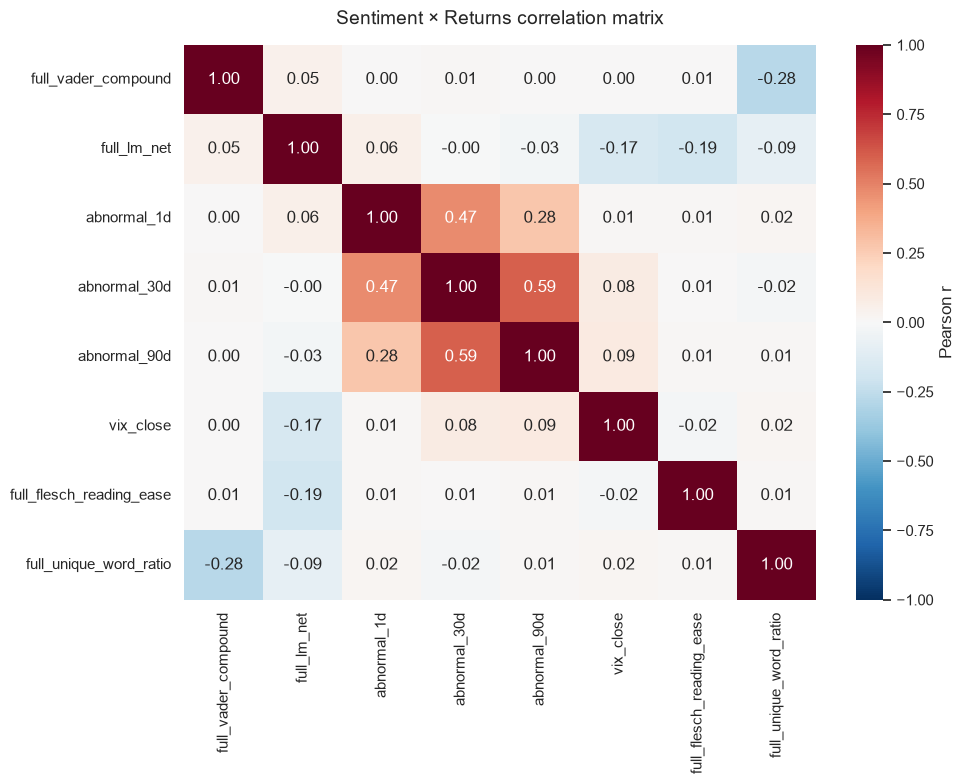

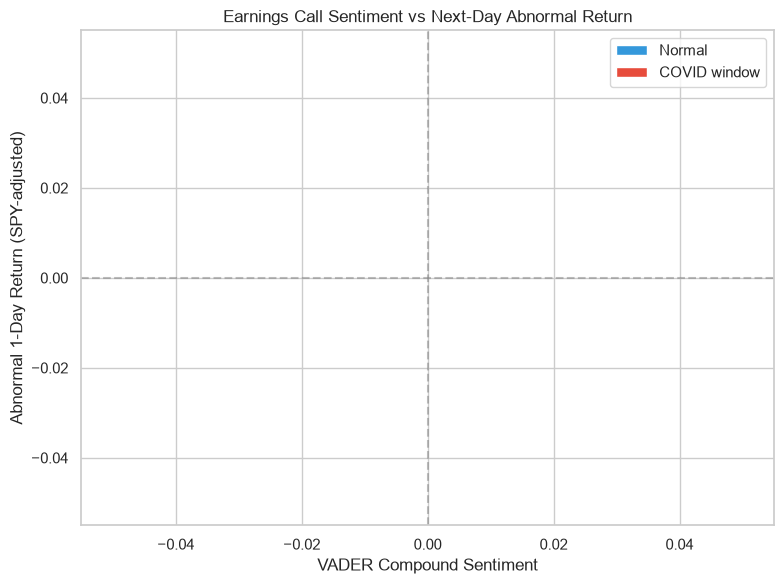

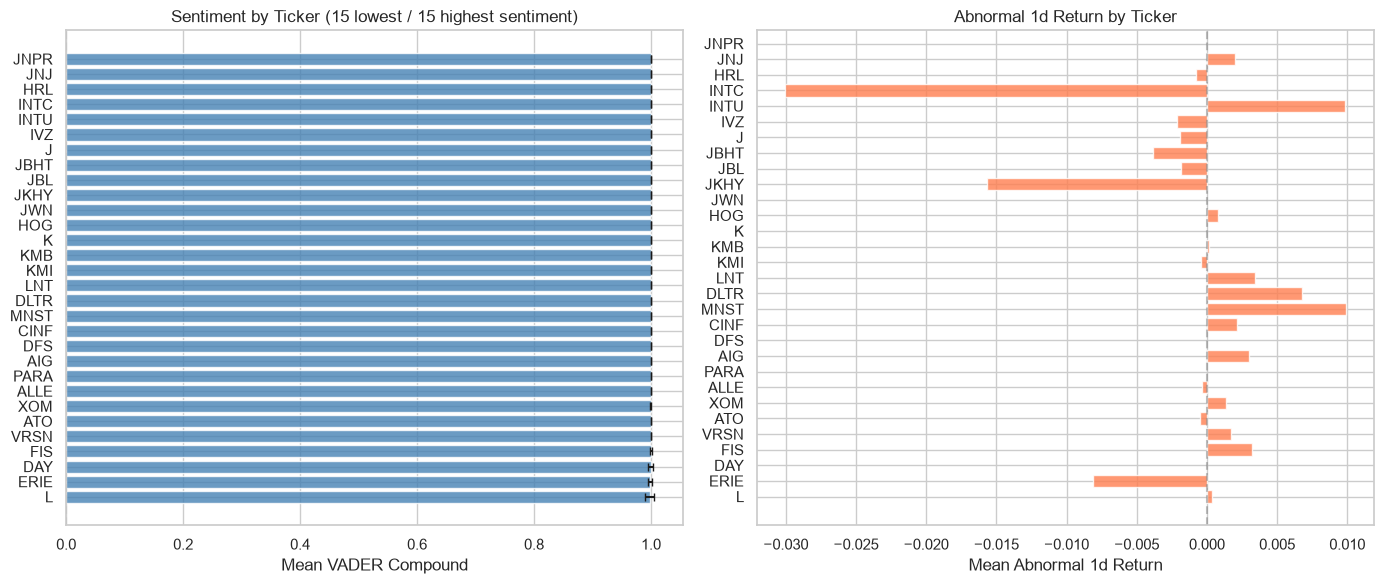

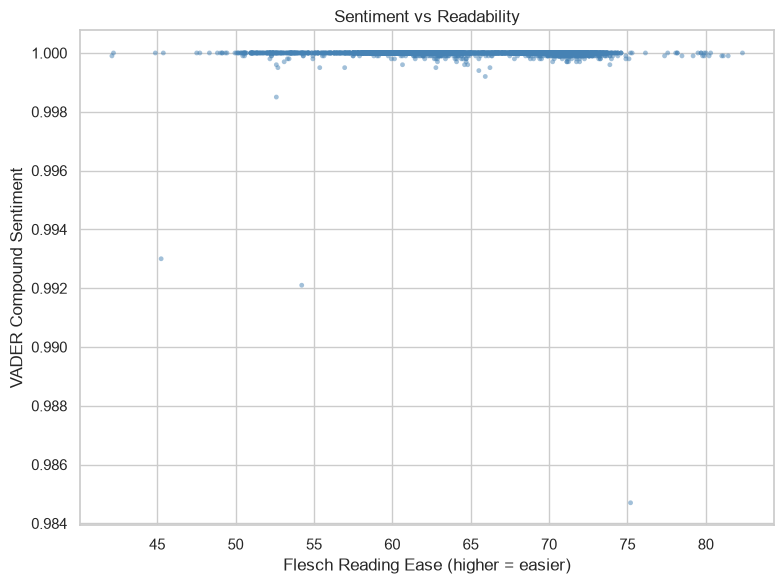

In [9]:
if len(df_merged) < 3:
    print(f'⚠️  Only {len(df_merged)} matched transcripts — '
          f'skipping visualizations (need ≥ 3 for meaningful plots).')
    print('Run 02b_ingest_hf_transcripts.ipynb first.')
else:
    fig, ax = plt.subplots(figsize=(10, 8))
    corr_cols = [c for c in ['full_vader_compound', 'full_lm_net', 'full_finbert_net',
                              'abnormal_1d', 'abnormal_30d', 'abnormal_90d',
                              'vix_close', 'full_flesch_reading_ease',
                              'full_unique_word_ratio']
                 if c in df_merged.columns and df_merged[c].notna().any()]
    corr = df_merged[corr_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax,
                cbar_kws={'label': 'Pearson r'})
    ax.set_title('Sentiment × Returns correlation matrix', fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

    if 'full_vader_compound' in df_merged.columns and 'abnormal_1d' in df_merged.columns:
        # Downsample the scatter beyond 5k points; only label tiny universes
        plot_df = (df_merged.sample(5000, random_state=42)
                   if len(df_merged) > 5000 else df_merged)
        fig, ax = plt.subplots(figsize=(8, 6))
        colors = plot_df['is_covid'].map({True: '#e74c3c', False: '#3498db'})
        size = 80 if len(plot_df) <= 500 else 12
        ax.scatter(plot_df['full_vader_compound'], plot_df['abnormal_1d'],
                   c=colors, alpha=0.5, edgecolors='none', s=size)
        if len(plot_df) <= 80:
            for _, row in plot_df.iterrows():
                ax.annotate(f"{row['ticker']} {row['quarter']}{row['year']}",
                            (row['full_vader_compound'], row['abnormal_1d']),
                            fontsize=7, alpha=0.7,
                            textcoords='offset points', xytext=(5, 5))
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('VADER Compound Sentiment')
        ax.set_ylabel('Abnormal 1-Day Return (SPY-adjusted)')
        ax.set_title('Earnings Call Sentiment vs Next-Day Abnormal Return')
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#3498db', label='Normal'),
                           Patch(facecolor='#e74c3c', label='COVID window')]
        ax.legend(handles=legend_elements, loc='best')
        plt.tight_layout()
        plt.show()

    if 'full_vader_compound' in df_merged.columns:
        ticker_sent = df_merged.groupby('ticker').agg(
            vader_mean=('full_vader_compound', 'mean'),
            vader_std=('full_vader_compound', 'std'),
            count=('full_vader_compound', 'count'),
            abn_1d_mean=('abnormal_1d', 'mean'),
        ).sort_values('vader_mean')
        # 685 tickers don't fit on one axis — show the 15 most negative
        # and 15 most positive names (plus everything when small)
        if len(ticker_sent) > 40:
            shown = pd.concat([ticker_sent.head(15), ticker_sent.tail(15)])
            title_suffix = ' (15 lowest / 15 highest sentiment)'
        else:
            shown = ticker_sent
            title_suffix = ''
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        ax1.barh(shown.index, shown['vader_mean'],
                 xerr=shown['vader_std'], capsize=3,
                 color='steelblue', alpha=0.8)
        ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax1.set_xlabel('Mean VADER Compound')
        ax1.set_title(f'Sentiment by Ticker{title_suffix}')
        ax2.barh(shown.index, shown['abn_1d_mean'],
                 color='coral', alpha=0.8)
        ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Mean Abnormal 1d Return')
        ax2.set_title('Abnormal 1d Return by Ticker')
        plt.tight_layout()
        plt.show()

    if 'full_vader_compound' in df_merged.columns and 'full_flesch_reading_ease' in df_merged.columns:
        plot_df = (df_merged.sample(5000, random_state=42)
                   if len(df_merged) > 5000 else df_merged)
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(plot_df['full_flesch_reading_ease'], plot_df['full_vader_compound'],
                   c='steelblue', alpha=0.5, s=(80 if len(plot_df) <= 500 else 12),
                   edgecolors='none')
        ax.set_xlabel('Flesch Reading Ease (higher = easier)')
        ax.set_ylabel('VADER Compound Sentiment')
        ax.set_title('Sentiment vs Readability')
        plt.tight_layout()
        plt.show()

## Summary & next steps

This notebook computed:
- **VADER** chunk-level sentiment scores
- **Loughran-McDonald** financial dictionary counts
- **FinBERT** transformer-based sentiment (GPU-accelerated)
- **Readability** and **linguistic** metrics

**New**: Features are computed **per transcript section**:
- `full_*` — entire cleaned transcript (backward compatible)
- `prepared_remarks_*` — scripted management remarks only
- `qa_*` — unscripted Q&A session only (available for ~40-50% of transcripts)
- `has_qa` — binary flag: 1 if Q&A section was found

The Q&A section is where genuine sentiment signals are expected to leak,
since prepared remarks are scripted boilerplate.

Results saved to `sentiment_features` table in `market.db`.

**Next**: `04_modeling.ipynb` — LightGBM regression with Q&A-section features